In [ ]:
!pip install upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=41b05670e6030676e374a6901a552794d2666116a9321b58d2e8503bfca40aba
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


In [ ]:
import pandas as pd
from matplotlib import cm
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

df = pd.read_csv("query_upset.csv")
df.head(5)

,bgc_id,family_id,organism,bin_label
0,9,1,P. cystidiosus,NRPS-like
1,174,1,P. cornucopiae,NRPS-like
2,611,1,P. ostreatus,NRPS-like
3,814,1,P. eryngii,NRPS-like
4,898,1,P. placentodes,NRPS-like


In [ ]:
grouped = df.groupby("family_id").agg({
    "organism": lambda x: list(set(x)),  # espécies únicas
    "bin_label": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]  # tipo mais frequente
}).reset_index()

grouped["memberships"] = grouped["organism"].apply(lambda x: tuple(sorted(x)))  # tuple p/ hashing
grouped["bin_label"] = grouped["bin_label"]

upset_data = from_memberships(grouped["memberships"], data=grouped["bin_label"])

upset_data.head(5)


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)


P. albidus  P. cornucopiae  P. cystidiosus  P. djamor  P. eryngii  P. ostreatoroseus  P. ostreatus  P. placentodes  P. pulmonarius
True        True            True            False      True        False              True          True            True              NRPS-like
False       False           False           True       False       False              False         False           False             NRPS-like
True        True            False           False      True        False              True          False           True              NRPS-like
                                                       False       False              True          False           True              NRPS-like
            False           False           False      True        False              False         False           False             NRPS-like
Name: bin_label, dtype: object

In [ ]:
pip install --upgrade upsetplot


/usr/local/lib/python3.12/dist-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/

Aviso: Um TypeError interno do Upsetplot foi ignorado. Erro: object of type 'list_reverseiterator' has no len()


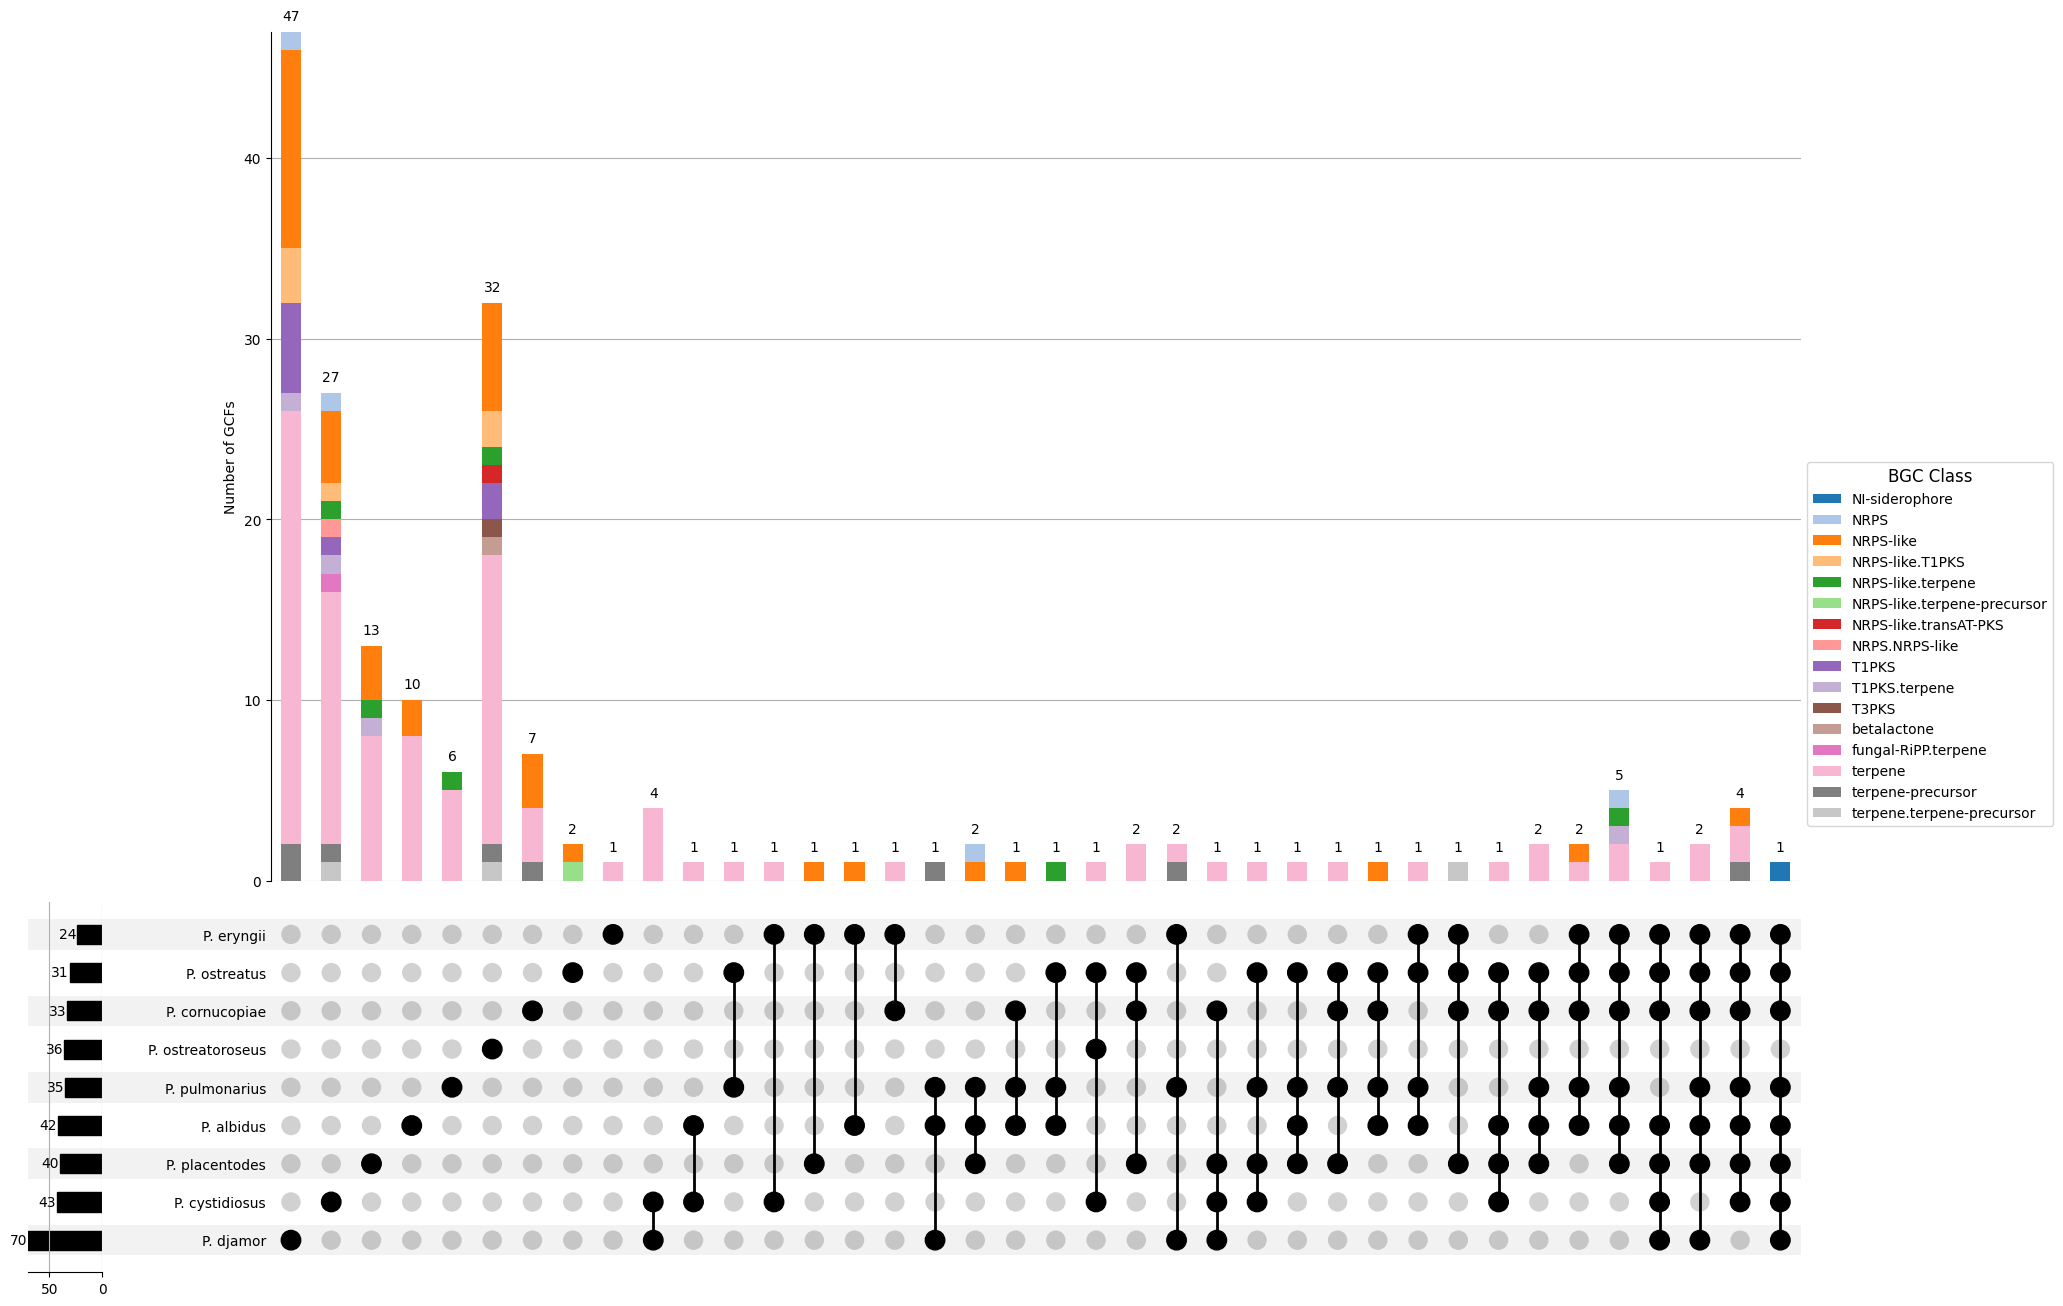

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch
from upsetplot import UpSet, from_memberships

try:
    df = pd.read_csv("query_upset.csv")
except FileNotFoundError:
    print("Erro: O arquivo CSV não foi encontrado.")
    exit()

# Esta linha remove espaços em branco do início e do fim de cada nome na coluna "organism".
df['organism'] = df['organism'].str.strip()

# PREPARAÇÃO DE DADOS
grouped = df.groupby("family_id").agg({
    "organism": lambda x: list(set(x)),
    "bin_label": lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
}).reset_index()

grouped["memberships"] = grouped["organism"].apply(lambda x: tuple(sorted(x)))

upset_df = from_memberships(grouped["memberships"])
upset_df = upset_df.to_frame(name="count")
upset_df["bin_label"] = grouped.set_index(upset_df.index)["bin_label"]




# Preparar Cores e Legenda (usando a paleta 'tab20' com cores distintas)
bin_labels_unique = sorted([label for label in upset_df["bin_label"].unique() if pd.notna(label)])
colors_to_use = list(cm.tab20.colors)
color_dict = {label: colors_to_use[i % len(colors_to_use)] for i, label in enumerate(bin_labels_unique)}


# 1. Inicializa o gráfico (baseado em famílias para o visual de cima ficar certo)
upset = UpSet(
    upset_df,
    subset_size='count',
    show_counts=True,    # Ativa a exibição do número ao lado da barra
    sort_by='degree',
    element_size=40,
    intersection_plot_elements=0
)

# a contagem de BGCs direto do CSV 'df'
contagem_real_bgcs = df['organism'].value_counts()

# Isso substitui o valor de famílias pelo bruto, mantendo o nome da espécie limpo
upset.totals = contagem_real_bgcs.reindex(upset.totals.index)

# 3. Adiciona as barras coloridas (interseções por família)
upset.add_stacked_bars(
    by="bin_label",
    colors=color_dict,
    title="Number of GCFs",
    elements=20
)

# 4. Desenha o gráfico na figura
fig = plt.figure(figsize=(40, 10))
try:
    upset.plot(fig)
except TypeError as e:
    # Mantemos o seu tratamento de erro para versões específicas do library
    print(f"Aviso: Um TypeError interno do Upsetplot foi ignorado. Erro: {e}")
    pass

# Ajuste da margem para a legenda não sobrepor o gráfico
fig.subplots_adjust(right=0.85)

# Criamos os handles com 'facecolor' para garantir a visualização
handles = [Patch(facecolor=color, label=label) for label, color in color_dict.items()]

# Legendas adicionadas no objeto FIGURA
fig.legend(
    handles=handles,
    title="BGC Class",
    loc='center left',
    bbox_to_anchor=(0.85, 0.5),
    title_fontsize='large',
    fontsize='medium'
)

# 6. Salvamento e Exibição
fig.savefig("grafico_final.svg", format="svg", bbox_inches="tight")
fig.savefig("grafico_final_com_legenda.png", dpi=300, bbox_inches='tight')

plt.show()

# Save as SVG
fig.savefig(
    "grafico_final.svg",
    format="svg",
    bbox_inches="tight"
)

# Save as PNG
fig.savefig("grafico_final_com_legenda.png", dpi=300, bbox_inches='tight')

plt.show()